## Assessing UniEload for LSTM Forecasting and SHAP Explanation

In [1]:
# Importing all the necessary libraries here
import pandas as pd
import seaborn as sns
import shap
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import axvline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from tensorflow.keras.optimizers import Adam

from statsmodels.graphics.tsaplots import plot_acf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import joblib

import warnings
warnings.filterwarnings("ignore")

c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


### Loading the Datasets

In [2]:
# Loading the electrical data
data_df = pd.read_csv("GSTU_Data_Final_With_Weather.csv")
print(f"{data_df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19008 entries, 0 to 19007
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Month                26 non-null     object 
 1   Date                 19008 non-null  object 
 2   Time                 19008 non-null  object 
 3   System_V             19008 non-null  int64  
 4   Current_R_A          19008 non-null  int64  
 5   Current_Y_A          19008 non-null  int64  
 6   Current_B_A          19008 non-null  int64  
 7   pf                   19008 non-null  float64
 8   Notes                3120 non-null   object 
 9   Temperature_C        19008 non-null  float64
 10  Humidity_%           19008 non-null  int64  
 11  Precipitation_mm     19008 non-null  float64
 12  Wind_Speed_mps       19008 non-null  float64
 13  Solar_Radiation_Wm2  19008 non-null  int64  
dtypes: float64(4), int64(6), object(4)
memory usage: 2.0+ MB
None


In [3]:
# Checking for missing values in the dataset
print(f"{data_df.isna().sum()}")

Month                  18982
Date                       0
Time                       0
System_V                   0
Current_R_A                0
Current_Y_A                0
Current_B_A                0
pf                         0
Notes                  15888
Temperature_C              0
Humidity_%                 0
Precipitation_mm           0
Wind_Speed_mps             0
Solar_Radiation_Wm2        0
dtype: int64


In [4]:
# Getting a statistical summary of the dataset
data_df.describe()

,System_V,Current_R_A,Current_Y_A,Current_B_A,pf,Temperature_C,Humidity_%,Precipitation_mm,Wind_Speed_mps,Solar_Radiation_Wm2
count,19008.000000,19008.000000,19008.000000,19008.000000,19008.000000,19008.000000,19008.000000,19008.000000,19008.000000,19008.000000
mean,432.490636,301.324127,300.696338,299.887784,0.985579,26.161658,75.775621,0.218692,8.856792,194.934606
std,5.288531,103.587913,110.926436,103.560800,0.007362,5.024896,17.533937,0.943036,4.857449,263.421586
min,412.000000,45.000000,90.000000,90.000000,0.900000,8.800000,15.000000,0.000000,0.000000,0.000000
25%,429.000000,210.000000,203.000000,206.000000,0.980000,23.700000,66.000000,0.000000,5.500000,0.000000
50%,432.000000,307.000000,304.000000,306.000000,0.990000,26.800000,80.000000,0.000000,7.900000,8.000000
75%,436.000000,382.000000,380.000000,380.000000,0.990000,29.400000,90.000000,0.000000,11.400000,392.250000
max,448.000000,985.000000,4566.000000,954.000000,0.990000,40.800000,100.000000,20.900000,55.500000,924.000000


### Data Cleaning

#### Dropping month column
- Month column is mostly empty due to how the excel sheet has been set up.  
- I just need the date and time column to interpret the time-series for my LSTM.

In [5]:
data_df2 = data_df.copy()
data_df2 = data_df2.drop(columns = ["Month"])

print(f"Shape before: {data_df.shape}")
print(f"Shape after: {data_df2.shape}")

Shape before: (19008, 14)
Shape after: (19008, 13)


#### Creating DatetimeIndex
- Merging date and time into Datetime_index and dropping legacy columns
    - it is locked as a strict chronological sequence
    - shifts time complexity to O(1) from O(N)

In [6]:
if "Date" in data_df2.columns and "Time" in data_df2.columns:
    # 1. Combine Date and Time
    combined_timestamps = data_df2["Date"].astype(str) + " " + data_df2["Time"].astype(str)
    data_df2["Datetime_index"] = pd.to_datetime(combined_timestamps, format="mixed", errors="coerce")

    # 2. Dropping original Date and Time columns 
    data_df2 = data_df2.drop(columns=["Date", "Time"])
    data_df2 = data_df2.set_index("Datetime_index").sort_index()
else:
    print(f"Datetime already exists")

print(f"{data_df2.index[:10]}")

DatetimeIndex(['2023-08-01 00:00:00', '2023-08-01 01:00:00',
               '2023-08-01 02:00:00', '2023-08-01 03:00:00',
               '2023-08-01 04:00:00', '2023-08-01 05:00:00',
               '2023-08-01 06:00:00', '2023-08-01 07:00:00',
               '2023-08-01 08:00:00', '2023-08-01 09:00:00'],
              dtype='datetime64[ns]', name='Datetime_index', freq=None)


#### Populating nulls in Notes
- Creating binary flag for vacation

In [7]:
# Creating binary flag: 1 if 'vacation' is in Notes, 0 otherwise
data_df2["is_vacation"] = data_df2["Notes"].str.contains("vacation", na=False).astype(int)
data_df2[data_df2["is_vacation"] == 1][["is_vacation", "Notes"]].head(5)

,is_vacation,Notes
Datetime_index,,
2023-10-20 00:00:00,1,vacation
2023-10-20 01:00:00,1,vacation
2023-10-20 02:00:00,1,vacation
2023-10-20 03:00:00,1,vacation
2023-10-20 04:00:00,1,vacation


#### Outliers
Clipping all 3 eletrical parameter readings
- Voltage 
    - Already within the range specified in IEC 60038 / EN 50160 standards
- Pf (0, 1)
    - Already witin IEEE Standard 141
- Current (0, IQR cap)
    - Preserving legitimate peak operational demand dynamics while capping isolated sensor anomalies

In [8]:
# Current clipping: 0 - IQR cap
data_df3 = data_df2.copy()
for col in ["Current_R_A", "Current_Y_A", "Current_B_A"]:
    # Removing physically impossible readings (>1500A on a distribution feeder)
    data_df3[col] = data_df3[col].clip(upper=1500)
    
    # IQR on clean distribution
    q1 = data_df3[col].quantile(0.25)
    q3 = data_df3[col].quantile(0.75)
    iqr = q3 - q1
    upper_lim = q3 + (2 * iqr)
    lower_lim = max(0, q1 - (2 * iqr))
    
    outliers = ((data_df3[col] < lower_lim) | (data_df3[col] > upper_lim)).sum()
    print(f"{col}: [{lower_lim:.0f}A, {upper_lim:.0f}A], {outliers} outliers clipped")
    data_df3[col] = data_df3[col].clip(lower=lower_lim, upper=upper_lim)

Current_R_A: [0A, 726A], 12 outliers clipped
Current_Y_A: [0A, 734A], 14 outliers clipped
Current_B_A: [0A, 728A], 17 outliers clipped


#### Flagging unexpected events
1. Current imbalance flag
    - to identify anomaly in LSTM training as it is not standard usage trend and distorts active power calculations
2. Current overload flag
    - to account for localized substation capacity constraints and severe thermal loading thresholds and it provides a clear operational condition for downstream post-hoc XAI
3. Peak time low load flag
    - indicator to explain sharp drop-offs in active power demand that weather patterns alone cannot account for

In [9]:
# Current unbalance factor: NEMA standard flags >2% as abnormal
data_df3["I_mean"] = data_df3[["Current_R_A", "Current_Y_A", "Current_B_A"]].mean(axis=1)
data_df3["I_std"] = data_df3[["Current_R_A", "Current_Y_A", "Current_B_A"]].std(axis=1)
data_df3["phase_imbalance_pct"] = (data_df3["I_std"] / data_df3["I_mean"]) * 100

severe_imbalance = (data_df3["phase_imbalance_pct"] > 20).sum()
moderate_imbalance = ((data_df3["phase_imbalance_pct"] > 10) & (data_df3["phase_imbalance_pct"] <= 20)).sum()
print(f"Severe phase imbalance (>20%): {severe_imbalance}")
print(f"Moderate phase imbalance (>10%): {moderate_imbalance}")

data_df3["imbalance_flag"] = (data_df3["phase_imbalance_pct"] > 20).astype(int)

Severe phase imbalance (>20%): 5006
Moderate phase imbalance (>10%): 5749


In [10]:
# Flagging readings where any phase current exceeds 90% of observed max as overload events
overload_threshold = data_df3[["Current_R_A", "Current_Y_A", "Current_B_A"]].max().max() * 0.90
data_df3["overload_flag"] = (data_df3[["Current_R_A", "Current_Y_A", "Current_B_A"]].max(axis=1) > overload_threshold).astype(int)
print(f"\nOverload events (>90% of max current): {data_df3['overload_flag'].sum()}")


Overload events (>90% of max current): 27


In [11]:
# Current below 5th percentile during peak hours is suspicious
peak_mask = (data_df3.index.hour >= 8) & (data_df3.index.hour < 22)
low_load_threshold = data_df3.loc[peak_mask, "I_mean"].quantile(0.05)
data_df3["low_load_flag"] = (peak_mask & (data_df3["I_mean"] < low_load_threshold)).astype(int)
print(f"Low load during peak hours: {data_df3['low_load_flag'].sum()}")

Low load during peak hours: 553


#### Advanced Feature Enigneering
1. Voltage sag detection
    - when campus demand rises and more current (I) is pulled through cables, voltage drops due
    - negative slope tells me exactly how many volts the system naturally drops for every single ampere drawn by the campus
    - calculates the difference between what the voltage should be under that load versus what it actually is
    $$e_t = V_{\text{system}, t} - \hat{V}_{\text{system}, t}$$
    - specifically isolates heavy inductive start-up strains or localized short-circuit faults
$$\text{v\_sag\_high\_i\_flag}_t = \begin{cases} 
1, & \text{if } e_t < (\bar{e} - 2\sigma) \ \ \mathbf{\text{and}} \ \ I_{\text{mean}, t} > \mathcal{Q}_{0.60}(I_{\text{mean}}) \\ 
0, & \text{otherwise} 
\end{cases}$$
This indicator alerts the LSTM network to structural voltage sags caused by localized high-impedance anomalies or massive inductive startup currents, isolating these severe transient spikes from forecasting trends

In [12]:
# Fitting a linear regression: voltage ~ current
slope, intercept, r_value, p_value, std_err = stats.linregress(data_df3["I_mean"], data_df3["System_V"]) # Voltage drops as current rises (negative slope expected)

print(f"Slope: {slope:.4f} V/A")
print(f"R²: {r_value**2:.4f}")

# Expected voltage for each current reading
data_df3["V_expected"] = intercept + slope * data_df3["I_mean"]

# Residual = actual voltage - expected voltage
# A large negative residual means voltage is much lower than expected; given the current level — that is the real sag signature
data_df3["V_residual"] = data_df3["System_V"] - data_df3["V_expected"]

# Flagging where residual is more than 2 standard deviations below expected
residual_std = data_df3["V_residual"].std()
residual_mean = data_df3["V_residual"].mean()
threshold = residual_mean - 2 * residual_std

high_current_threshold = data_df3["I_mean"].quantile(0.60)

data_df3["v_sag_high_i_flag"] = ((data_df3["V_residual"] < threshold) & (data_df3["I_mean"] > high_current_threshold)).astype(int)

print(f"\nResidual threshold: {threshold:.2f}V")
print(f"Flagged sag events: {data_df3['v_sag_high_i_flag'].sum()}")
print(f"As % of total: {data_df3['v_sag_high_i_flag'].mean()*100:.2f}%")

Slope: -0.0030 V/A
R²: 0.0030

Residual threshold: -10.56V
Flagged sag events: 238
As % of total: 1.25%


2. Creating Active Power ($kW$) for LSTM prediction

$$P_{\text{active}} \text{(kW)} = \frac{\sqrt{3} \times V_{\text{system}} \times I_{\text{mean}} \times \text{pf}}{1000}$$

Where:
* $\sqrt{3}$: Mathematical constant for three-phase balanced systems.
* $V_{\text{system}}$: Line-to-line voltage (`System_V`).
* $I_{\text{mean}}$: Mean phase current derived from $\frac{I_R + I_Y + I_B}{3}$.
* $\text{pf}$: Measured power factor (`pf`).


In [52]:
# Calculating active power in kW
data_df3["Active_Power_kw"] = (np.sqrt(3) * data_df3["System_V"] * data_df3["I_mean"] * data_df3["pf"]) / 1000
print(f"\nMax: {data_df3['Active_Power_kw'].max():.1f}kW\nMin: {data_df3['Active_Power_kw'].min():.1f}kW\nMean: {data_df3['Active_Power_kw'].mean():.1f}kW")


Max: 536.5kW
Min: 69.0kW
Mean: 222.1kW


3. Cooling Degree Hours (CDH)
    - Capturing non-linear relationship between ambient temperature and HVAC electricity consumption
    $$\text{CDH} = \max(0, T_{\text{ambient}} - 24.0)$$

In [ ]:
# Cooling degree hours
cooling_base_temp = 24.0  # human thermal comfort baseline
data_df3["cdh"] = (data_df3["Temperature_C"] - cooling_base_temp).clip(lower=0)

In [15]:
print(f"\nFinal shape: {data_df3.shape}")
print(f"Date range: {data_df3.index.min()} to {data_df3.index.max()}")
print(f"\nActive power range: {data_df3['Active_Power_kw'].min():.1f} to {data_df3['Active_Power_kw'].max():.1f} kW")
print(f"\nEngineered flags summary:")
print(f"{round(data_df3[['imbalance_flag','overload_flag','low_load_flag','v_sag_high_i_flag', 'Active_Power_kw', 'cdh']].sum())}")


Final shape: (19008, 23)
Date range: 2023-08-01 00:00:00 to 2025-09-30 23:00:00

Active power range: 69.0 to 536.5 kW

Engineered flags summary:
imbalance_flag          5006.0
overload_flag             27.0
low_load_flag            553.0
v_sag_high_i_flag        238.0
Active_Power_kw      4216379.0
cdh                    64015.0
dtype: float64


#### Visuals for Analysis

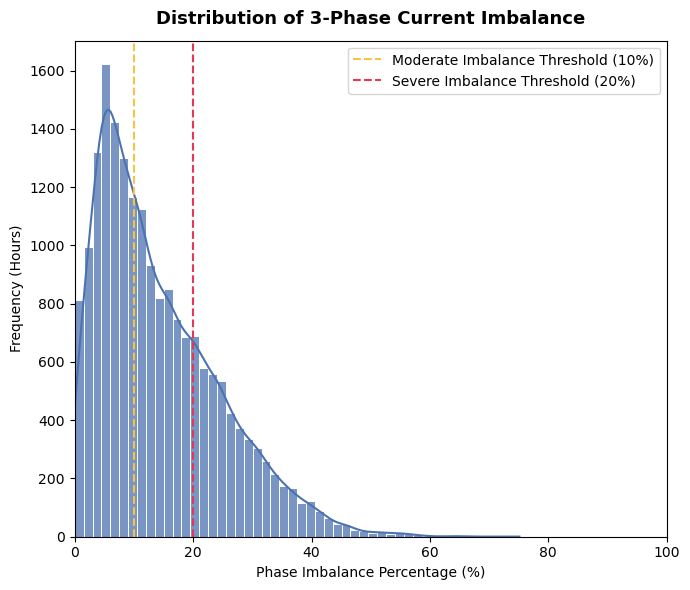

In [16]:
fig = plt.figure(figsize=(7, 6))

# Plotting the distribution of phase imbalance percentage
sns.histplot(data=data_df3, x="phase_imbalance_pct", kde=True, color="#4c72b0", bins=50, edgecolor="white", alpha=0.75)

axvline(10, color="#f6c343", linestyle="--", linewidth=1.5, label="Moderate Imbalance Threshold (10%)")
axvline(20, color="#e63757", linestyle="--", linewidth=1.5, label="Severe Imbalance Threshold (20%)")

plt.title("Distribution of 3-Phase Current Imbalance", fontsize=13, pad=12, weight='bold')
plt.xlabel("Phase Imbalance Percentage (%)")
plt.ylabel("Frequency (Hours)")
plt.xlim(0, 100)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("phase_imbalance_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

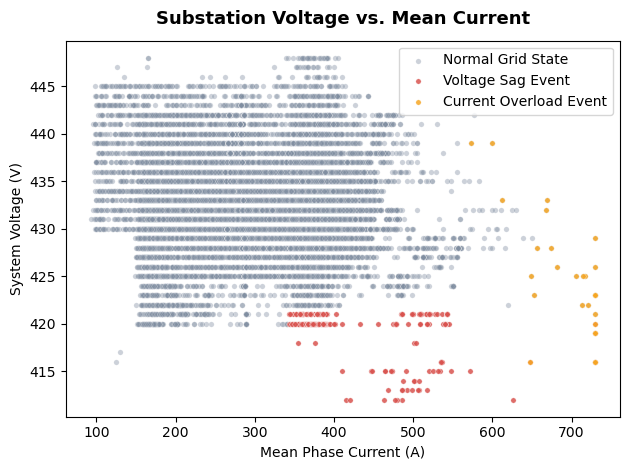

In [17]:
# Plotting distribution of system voltage vs mean current
# Normal grid state events
sns.scatterplot(data=data_df3[data_df3["v_sag_high_i_flag"] == 0], x="I_mean", y="System_V", 
                color="#808ea1", alpha=0.4, s=15, label="Normal Grid State")

# Voltage sag events
sns.scatterplot(data=data_df3[data_df3["v_sag_high_i_flag"] == 1], x="I_mean", 
                y="System_V", color="#d9534f", alpha=0.85, s=15, label="Voltage Sag Event")

# Current overload events
sns.scatterplot(data=data_df3[data_df3["overload_flag"] == 1], x="I_mean", y="System_V", 
                color="#f6a623", alpha=0.85, s=15, label="Current Overload Event")

plt.title("Substation Voltage vs. Mean Current", fontsize=13, pad=12, weight='bold')
plt.xlabel("Mean Phase Current (A)")
plt.ylabel("System Voltage (V)")
plt.legend(loc="best")

plt.tight_layout()
plt.savefig("substation_voltage_vs_current.png", dpi=300, bbox_inches='tight')
plt.show()

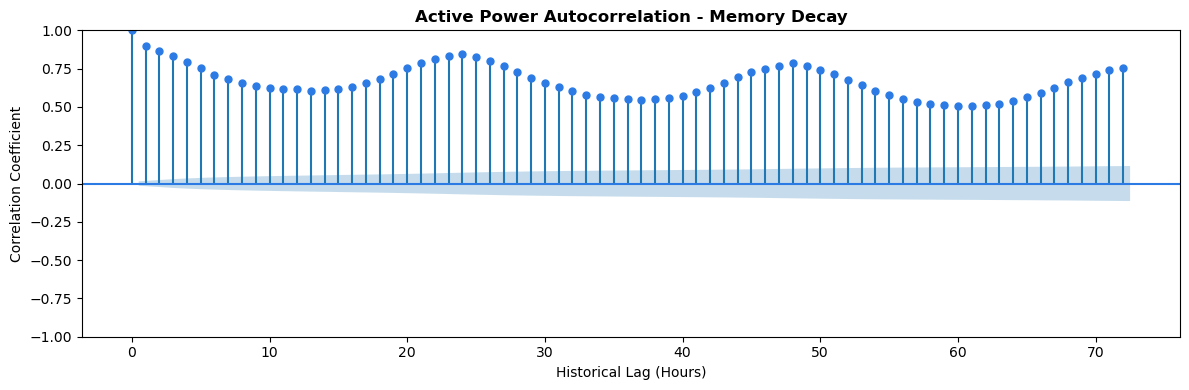

In [ ]:
# Using subplots to create a more compact plot
fig, ax = plt.subplots(figsize=(12, 4))

# Autocorrelation up to 72 hours back to capture daily cycles
plot_acf(data_df3["Active_Power_kw"], lags=72, alpha=0.05, color="#2c7be5", ax=ax)
ax.set_title("Active Power Autocorrelation - Memory Decay", weight='bold')
ax.set_xlabel("Historical Lag (Hours)")
ax.set_ylabel("Correlation Coefficient")

plt.tight_layout()
plt.savefig("target_autocorrelation_acf.png", dpi=300)
plt.show()

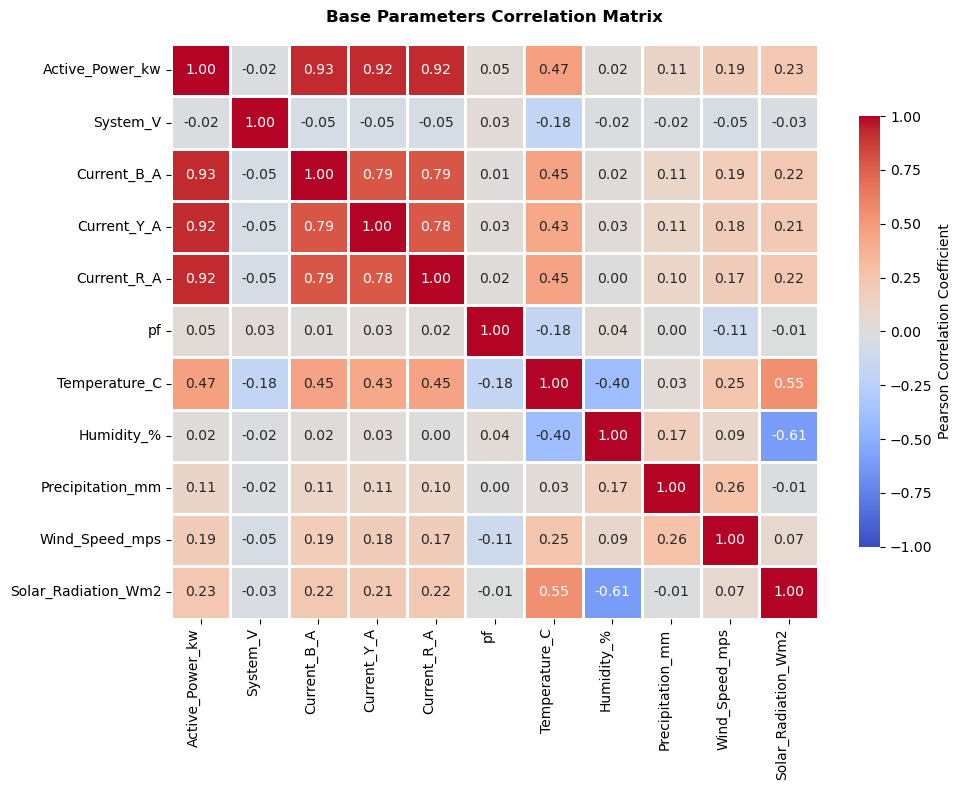

In [19]:
fig = plt.figure(figsize=(10, 8))

# Target features for correlation analysis
initial_features = ["Active_Power_kw", "System_V", "Current_B_A", "Current_Y_A", "Current_R_A", "pf", "Temperature_C", 
            "Humidity_%", "Precipitation_mm", "Wind_Speed_mps", "Solar_Radiation_Wm2"] 
    
# Filtering df to compute the correlation matrix
matrix_data = data_df3[[col for col in initial_features if col in data_df3.columns]]
corr_matrix = matrix_data.corr()

# Heatmap for correlation matrix
sns.heatmap(corr_matrix, cmap="coolwarm", vmax=1.0, vmin=-1.0, center=0, annot=True, fmt=".2f", 
            linewidths=0.75, cbar_kws={"shrink": 0.75, "label": "Pearson Correlation Coefficient"})

plt.title("Base Parameters Correlation Matrix", fontsize=12, pad=16, weight='bold')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("base_parameters_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

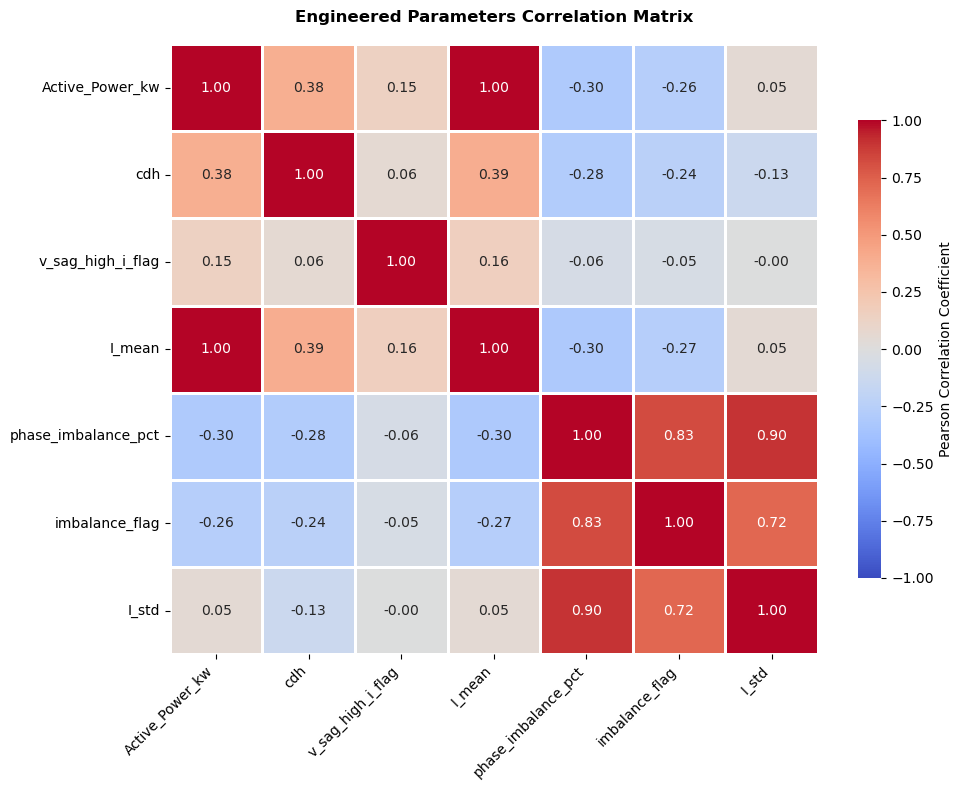

In [20]:
# Select Target + Engineered Features
eng_features = ["Active_Power_kw", "cdh", "v_sag_high_i_flag", "I_mean", "phase_imbalance_pct", "imbalance_flag", "I_std"]

# Filtering engineerd features
eng_matrix_data = data_df3[[col for col in eng_features if col in data_df3.columns]]
eng_corr_matrix = eng_matrix_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(eng_corr_matrix, cmap="coolwarm", vmax=1.0, vmin=-1.0, center=0, annot=True, fmt=".2f", 
            linewidths=0.75, cbar_kws={"shrink": 0.75, "label": "Pearson Correlation Coefficient"})

plt.title("Engineered Parameters Correlation Matrix", fontsize=12, pad=16, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("engineered_parameters_corr.png", dpi=300, bbox_inches="tight")
plt.show()

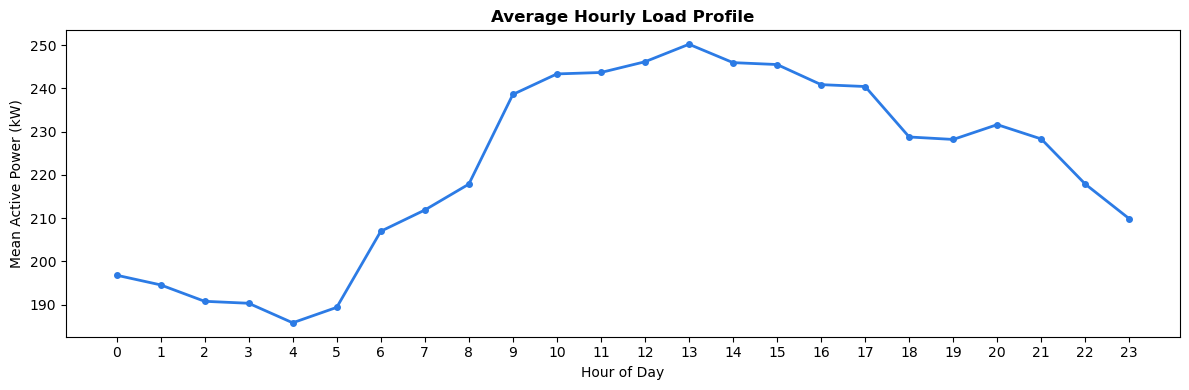

In [21]:
fig = plt.figure(figsize=(12, 4))

# Average hourly load profile
data_df3.groupby(data_df3.index.hour)["Active_Power_kw"].mean().plot(color="#2c7be5", linewidth=2, marker="o", markersize=4)
plt.title("Average Hourly Load Profile", weight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Active Power (kW)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("hourly_load_profile.png", dpi=300, bbox_inches="tight")
plt.show()

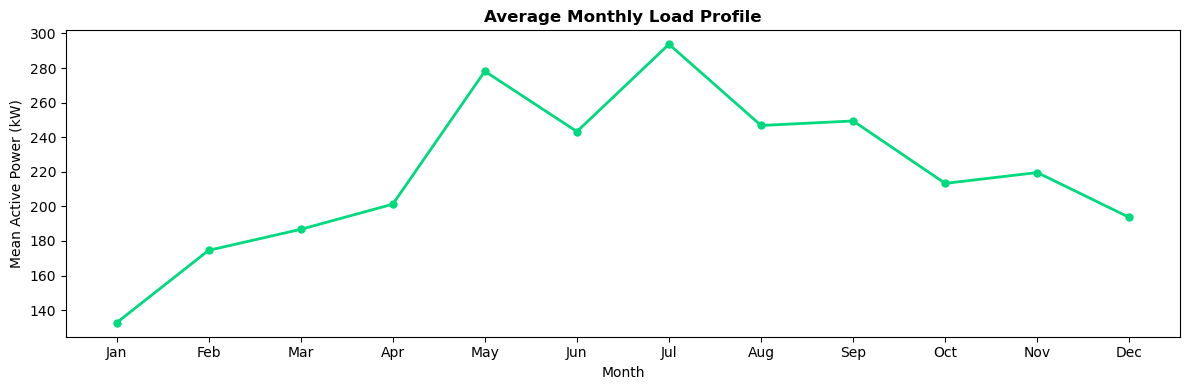

In [22]:
fig = plt.figure(figsize=(12, 4))

# Average monthly load profile
data_df3.groupby(data_df3.index.month)["Active_Power_kw"].mean().plot(color="#00d97e", linewidth=2, marker="o", markersize=5)
plt.title("Average Monthly Load Profile", weight="bold")
plt.xlabel("Month")
plt.ylabel("Mean Active Power (kW)")
plt.xticks(range(1, 13))
plt.gca().set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.savefig("monthly_load_profile.png", dpi=300, bbox_inches="tight")
plt.show()

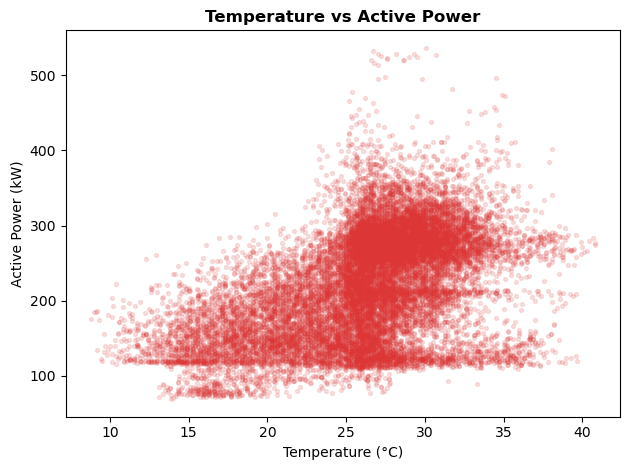

In [23]:
# Scatter plot of temperature vs active power
plt.scatter(data_df3["Temperature_C"], data_df3["Active_Power_kw"], alpha=0.15, s=8, color="#dd3636")
plt.title("Temperature vs Active Power", weight="bold")
plt.xlabel("Temperature (°C)")
plt.ylabel("Active Power (kW)")
plt.tight_layout()
plt.savefig("temp_vs_power.png", dpi=300, bbox_inches="tight")
plt.show()

#### Preprocessing

In [24]:
# Adding cyclical temporal features for LSTM
data_df3["hour_sin"] = np.sin(2 * np.pi * data_df3.index.hour / 24.0)
data_df3["hour_cos"] = np.cos(2 * np.pi * data_df3.index.hour / 24.0)
data_df3["month_sin"] = np.sin(2 * np.pi * data_df3.index.month / 12.0)
data_df3["month_cos"] = np.cos(2 * np.pi * data_df3.index.month / 12.0)

In [25]:
# Dropping unnecessary columns
cols_to_drop = ["V_expected", "V_residual", "I_std", "imbalance_flag", "overload_flag", "low_load_flag", "v_sag_high_i_flag", "Notes"]
data_df3 = data_df3.drop(columns=cols_to_drop, errors="ignore")
print(data_df3.info())

# Saving a cleaned version of the df
data_df3.to_csv("gstu_cleaned.csv")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19008 entries, 2023-08-01 00:00:00 to 2025-09-30 23:00:00
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   System_V             19008 non-null  int64  
 1   Current_R_A          19008 non-null  int64  
 2   Current_Y_A          19008 non-null  int64  
 3   Current_B_A          19008 non-null  int64  
 4   pf                   19008 non-null  float64
 5   Temperature_C        19008 non-null  float64
 6   Humidity_%           19008 non-null  int64  
 7   Precipitation_mm     19008 non-null  float64
 8   Wind_Speed_mps       19008 non-null  float64
 9   Solar_Radiation_Wm2  19008 non-null  int64  
 10  is_vacation          19008 non-null  int32  
 11  I_mean               19008 non-null  float64
 12  phase_imbalance_pct  19008 non-null  float64
 13  Active_Power_kw      19008 non-null  float64
 14  cdh                  19008 non-null  float64
 15  h

In [ ]:
# Final Feature Set preparation
# Defining lag steps for different power and temperature
lags = [24, 48, 168]

# Creating lags for Active Power
lag_features_dict = {f"power_lag_{lag}": data_df3["Active_Power_kw"].shift(lag)for lag in lags}

# Creating lags for Temperature
for lag in lags:
    lag_features_dict[f"temp_lag_{lag}"] = data_df3["Temperature_C"].shift(lag)

# Converting to DataFrame and concatenating
df_lags = pd.DataFrame(lag_features_dict, index=data_df3.index)
data_df3 = pd.concat([data_df3, df_lags], axis=1)

# Dropping NaNs created by shifting
rows_before = len(data_df3)
data_df3 = data_df3.dropna()

print(f"Rows dropped to satisfy longest lag (168h): {rows_before - len(data_df3)}")
print(f"Remaining rows: {len(data_df3)} | {len(data_df3)/rows_before:.1%}")

Rows dropped to satisfy longest lag (168h): 168
Remaining rows: 18840 | 99.1%


In [27]:
# Defining features and target for modeling
target = "Active_Power_kw"

lag_features = list(df_lags.columns)

base_features = [# Electrical parameters
    "System_V", "Current_R_A", "Current_Y_A", "Current_B_A", "pf", #"phase_imbalance_pct",
    # Meteorological parameters
    "Temperature_C", "Solar_Radiation_Wm2", "cdh", #"Precipitation_mm", "Wind_Speed_mps", "Humidity_%"
    # Temporal features
    "hour_sin", "hour_cos", "month_sin", "month_cos" #, "is_vacation",
    ]

features = base_features + lag_features

print("Model Features:", features)
print(f"\nTotal feature count: {len(features)}")


Model Features: ['System_V', 'Current_R_A', 'Current_Y_A', 'Current_B_A', 'pf', 'Temperature_C', 'Solar_Radiation_Wm2', 'cdh', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'power_lag_24', 'power_lag_48', 'power_lag_168', 'temp_lag_24', 'temp_lag_48', 'temp_lag_168']

Total feature count: 18


In [28]:
# Manually splitting chronologically: 70% Train, 15% Val, 15% Test
n = len(data_df3)
train_df = data_df3.iloc[:int(n*0.7)]
val_df = data_df3.iloc[int(n*0.7):int(n*0.85)]
test_df = data_df3.iloc[int(n*0.85):]

print(f"Total rows: {n}")
print(f"Trainning rows: {len(train_df)} ({len(train_df)/n*100:.1f}%)")
print(f"Validation rows: {len(val_df)} ({len(val_df)/n*100:.1f}%)")
print(f"Test rows: {len(test_df)} ({len(test_df)/n*100:.1f}%)")
print(f"\nTrain period: {train_df.index.min()} - {train_df.index.max()}")
print(f"Val period: {val_df.index.min()} - {val_df.index.max()}")
print(f"Test period: {test_df.index.min()} - {test_df.index.max()}")

Total rows: 18840
Trainning rows: 13188 (70.0%)
Validation rows: 2826 (15.0%)
Test rows: 2826 (15.0%)

Train period: 2023-08-08 00:00:00 - 2025-02-07 11:00:00
Val period: 2025-02-07 12:00:00 - 2025-06-05 05:00:00
Test period: 2025-06-05 06:00:00 - 2025-09-30 23:00:00


In [29]:
# Using Min-Max Scaling for Normalisation

# Separate scalers for features and target
# Fitting only on training data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_df[features])
X_val_scaled = scaler_X.transform(val_df[features])
X_test_scaled = scaler_X.transform(test_df[features])

y_train_scaled = scaler_y.fit_transform(train_df[[target]])
y_val_scaled = scaler_y.transform(val_df[[target]])
y_test_scaled = scaler_y.transform(test_df[[target]])

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_val shape: {X_val_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"\nFeature range after scaling:")
print(f"Min: {X_train_scaled.min():.4f}")
print(f"Max: {X_train_scaled.max():.4f}")
print(f"\nTarget range after scaling:")
print(f"Min: {y_train_scaled.min():.4f}")
print(f"Max: {y_train_scaled.max():.4f}")

# Save scalers — needed to inverse transform predictions back to kW
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

X_train shape: (13188, 18)
X_val shape: (2826, 18)
X_test shape: (2826, 18)

Feature range after scaling:
Min: 0.0000
Max: 1.0000

Target range after scaling:
Min: 0.0000
Max: 1.0000


['scaler_y.pkl']

In [30]:
# Lookback window: 48 hours - model to see last 48 hours of all features to predict
LOOKBACK = 48

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, LOOKBACK)
X_test_seq, y_test_seq = create_sequences(X_test_scaled,y_test_scaled, LOOKBACK)

print(f"Lookback window: {LOOKBACK} hours")
print(f"\nX_train_seq shape: {X_train_seq.shape} (samples, timesteps, features)")
print(f"X_val_seq shape: {X_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")
print(f"\ny_train_seq shape: {y_train_seq.shape}")
print(f"y_val_seq shape: {y_val_seq.shape}")
print(f"y_test_seq shape: {y_test_seq.shape}")

N_FEATURES = X_train_seq.shape[2]
print(f"\nInput shape for LSTM: ({LOOKBACK}, {N_FEATURES})")

Lookback window: 48 hours

X_train_seq shape: (13140, 48, 18) (samples, timesteps, features)
X_val_seq shape: (2778, 48, 18)
X_test_seq shape: (2778, 48, 18)

y_train_seq shape: (13140, 1)
y_val_seq shape: (2778, 1)
y_test_seq shape: (2778, 1)

Input shape for LSTM: (48, 18)


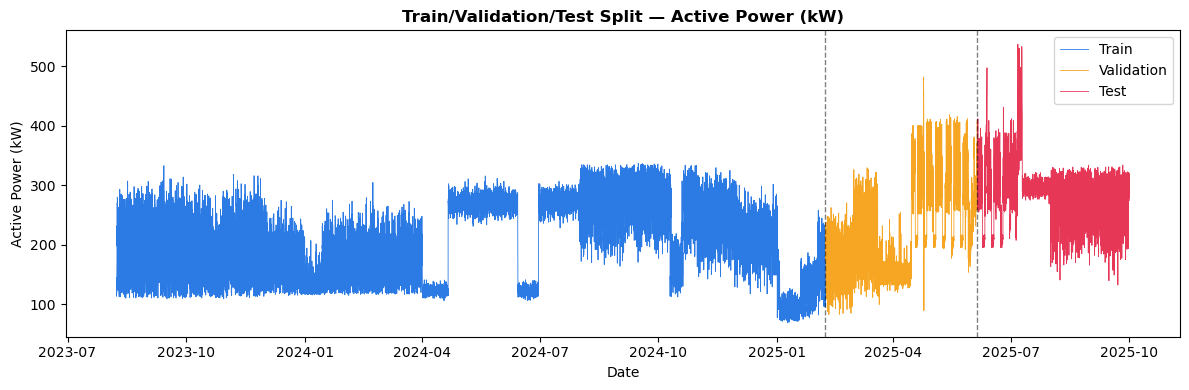

In [31]:
# Checking that the train/val/test split is clean and non-overlapping
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(train_df.index, train_df[target], color="#2c7be5", linewidth=0.6, label="Train")
ax.plot(val_df.index, val_df[target], color="#f6a623", linewidth=0.6, label="Validation")
ax.plot(test_df.index, test_df[target], color="#e63757", linewidth=0.6, label="Test")

ax.axvline(train_df.index[-1], color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axvline(val_df.index[-1],   color="black", linestyle="--", linewidth=1, alpha=0.5)

ax.set_title("Train/Validation/Test Split — Active Power (kW)", weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Active Power (kW)")
ax.legend()

plt.tight_layout()
plt.savefig("train_val_test_split.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
# Final confirmation
print("Final Configuration Summary:")
print(f"LSTM input shape: ({LOOKBACK}, {N_FEATURES})")
print(f"Train sequences: {X_train_seq.shape[0]}")
print(f"Validation sequences: {X_val_seq.shape[0]}")
print(f"Test sequences: {X_test_seq.shape[0]}")

Final Configuration Summary:
LSTM input shape: (48, 18)
Train sequences: 13140
Validation sequences: 2778
Test sequences: 2778


#### THE LSTM MODEL

##### Model Architecture
Best performing stacked two-layer LSTM:
- **Layer 1**: 64 units
- **Dropout 1**: 0.2
- **Layer 2**: 32 units
- **Dropout 2**: 0.2
- **Dense output**: 1 unit, linear activation — predicting the Active Power for the next hour

Compiled with the **Adam** optimiser (lr = 5e-4) and **MSE** loss.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

# Setting up my LSTM model architecture
def build_lstm(lookback, n_features, units_1=64, units_2=32, dropout_rate=0.2, lr=5e-4):
    model = Sequential([
        LSTM(units_1, return_sequences=True, input_shape=(lookback, n_features)),
        Dropout(dropout_rate),
        LSTM(units_2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1, activation="linear")
    ], name="LSTM_LoadForecaster")

    model.compile(
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        loss="mse", # was log_cosh in the original — MSE penalizes peak errors more harshly
        metrics=["mae"])
    return model

model = build_lstm(LOOKBACK, N_FEATURES)
model.summary()


Model: "LSTM_LoadForecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

#### Callbacks

1. **EarlyStopping** — monitoring `val_loss`; halts training if no improvement is seen for 15 consecutive epochs.
2. **ModelCheckpoint** — saving the best model weights to disk independently, providing a recovery point.
3. **ReduceLROnPlateau** — changes the learning rate if `val_loss` plateaus for 7 epochs, allowing fine-grained convergence once the learning rate is too coarse.

In [34]:
# Setting up callbacks for governing the performance
early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint(filepath="best_lstm_model.keras", monitor="val_loss", save_best_only=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6, verbose=1)

callbacks = [early_stop, checkpoint, reduce_lr]
print("Callbacks registered: EarlyStopping (patience=15) | ModelCheckpoint | ReduceLROnPlateau (patience=7)")


Callbacks registered: EarlyStopping (patience=15) | ModelCheckpoint | ReduceLROnPlateau (patience=7)


#### Training

In [35]:
# Training the model
batch_size = 64
max_epochs = 100

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=max_epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    shuffle=False,
    verbose=1)

print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

Epoch 1/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0520 - mae: 0.1762
Epoch 1: val_loss improved from None to 0.08748, saving model to best_lstm_model.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0399 - mae: 0.1560 - val_loss: 0.0875 - val_mae: 0.2286 - learning_rate: 5.0000e-04
Epoch 2/100
204/206 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0210 - mae: 0.1157
Epoch 2: val_loss improved from 0.08748 to 0.04417, saving model to best_lstm_model.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0209 - mae: 0.1145 - val_loss: 0.0442 - val_mae: 0.1550 - learning_rate: 5.0000e-04
Epoch 3/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0165 - mae: 0.1022
Epoch 3: val_loss improved from 0.04417 to 0.03915, saving model to best_lstm_model.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0169 - mae: 0.1024 - val_loss: 0.0391 - val_mae: 0.1462 - learning_rate: 5.0000e-04
Epoch 4/100
204/206 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0148 - mae: 

#### Learning Curves

Plotting training vs validation loss to verify convergence and check for overfitting.

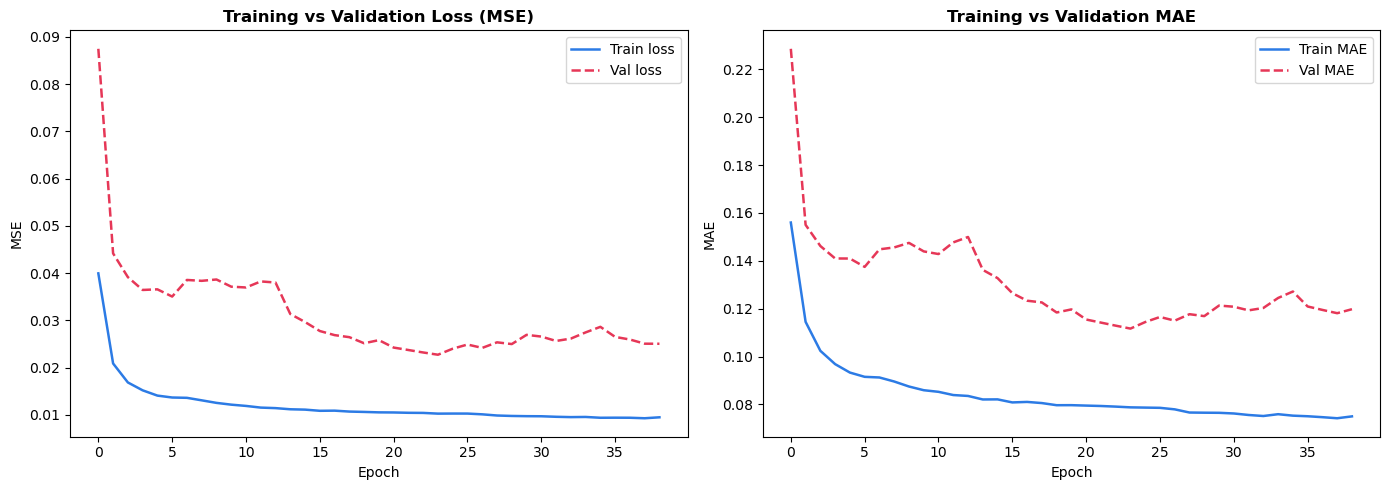

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PLotting the learning curves for Loss, MSE and MAE
axes[0].plot(history.history["loss"], color="#2c7be5", linewidth=1.8, label="Train loss")
axes[0].plot(history.history["val_loss"], color="#e63757", linewidth=1.8, linestyle="--", label="Val loss")
axes[0].set_title("Training vs Validation Loss (MSE)", weight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(history.history["mae"], color="#2c7be5", linewidth=1.8, label="Train MAE")
axes[1].plot(history.history["val_mae"], color="#e63757", linewidth=1.8, linestyle="--", label="Val MAE")
axes[1].set_title("Training vs Validation MAE", weight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.savefig("lstm_learning_curves.png", dpi=300, bbox_inches="tight")
plt.show()

#### Evaluation 
Predictions are inverse-transformed from the scaled [0, 1] space back to kilowatts using `scaler_y` before metric computation.

- **RMSE** — penalises large errors heavily; the primary benchmark metric in the STLF literature
- **MAE** — linear error; easier to interpret
- **MAPE** — allows comparison across datasets of different scales. Target benchmark: < 5% (Muzaffar & Afshari, 2019)

In [37]:
# Evaluating the model on the test set
y_pred_scaled = model.predict(X_test_seq, batch_size=batch_size)
y_pred_kw = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_kw = scaler_y.inverse_transform(y_test_seq).flatten()

# Calculating RMSE, MAE, and MAPE for the test set
rmse = np.sqrt(mean_squared_error(y_test_kw, y_pred_kw))
mae = mean_absolute_error(y_test_kw, y_pred_kw)
mask = y_test_kw > 1.0
mape = np.mean(np.abs((y_test_kw[mask] - y_pred_kw[mask]) / y_test_kw[mask])) * 100

print(f"{'RMSE':<10} {rmse:>10.3f}kW")
print(f"{'MAE':<10} {mae:>10.3f}kW")
print(f"{'MAPE':<10} {mape:>10.2f}%")
# retrained to full convergence. See the regime-split evaluation which shows where this model actually adds value over a naive baseline.


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
RMSE           35.225kW
MAE            25.129kW
MAPE             8.87%


#### Actual vs Predicted Plot

Visualising the first 7 days (168 hours) of the test period to assess temporal alignment between predictions and ground truth.

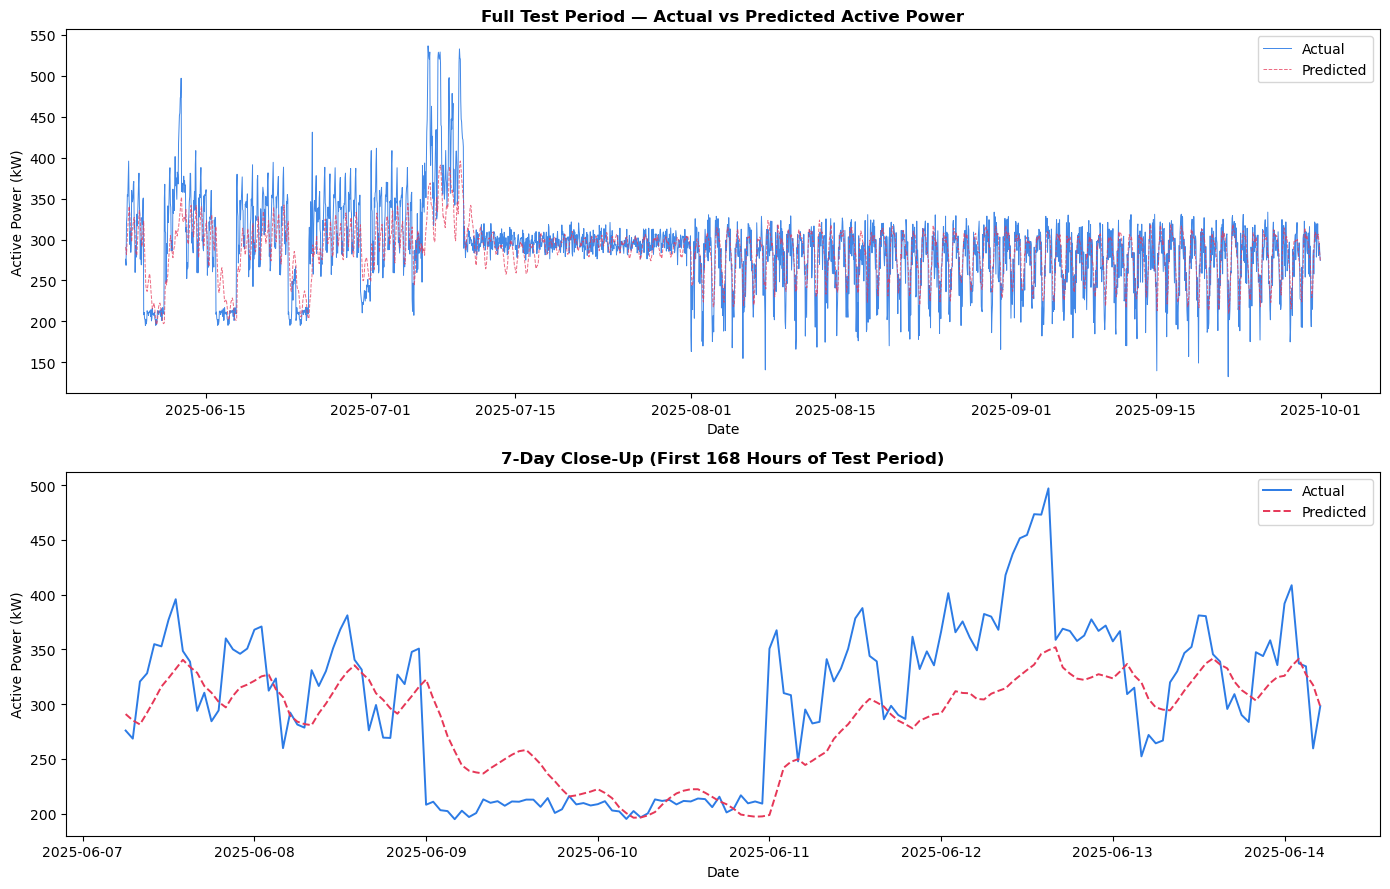

In [38]:
# Reconstructing the test DatetimeIndex — offset by lookback
test_index = test_df.index[LOOKBACK:]

# 7-day close-up
plot_hours = 168

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Full test period
axes[0].plot(test_index, y_test_kw, color="#2c7be5", linewidth=0.7, label="Actual", alpha=0.9)
axes[0].plot(test_index, y_pred_kw, color="#e63757", linewidth=0.7, label="Predicted", alpha=0.75, linestyle="--")
axes[0].set_title("Full Test Period — Actual vs Predicted Active Power", weight="bold")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Active Power (kW)")
axes[0].legend()

# 7-day close up
axes[1].plot(test_index[:plot_hours], y_test_kw[:plot_hours], color="#2c7be5", linewidth=1.4, label="Actual")
axes[1].plot(test_index[:plot_hours], y_pred_kw[:plot_hours], color="#e63757", linewidth=1.4, label="Predicted", linestyle="--")
axes[1].set_title("7-Day Close-Up (First 168 Hours of Test Period)", weight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Active Power (kW)")
axes[1].legend()

plt.tight_layout()
plt.savefig("lstm_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

#### Residual Analysis  

Examining the distribution and temporal pattern of prediction errors to identify systematic bias or heteroscedastic error patterns.

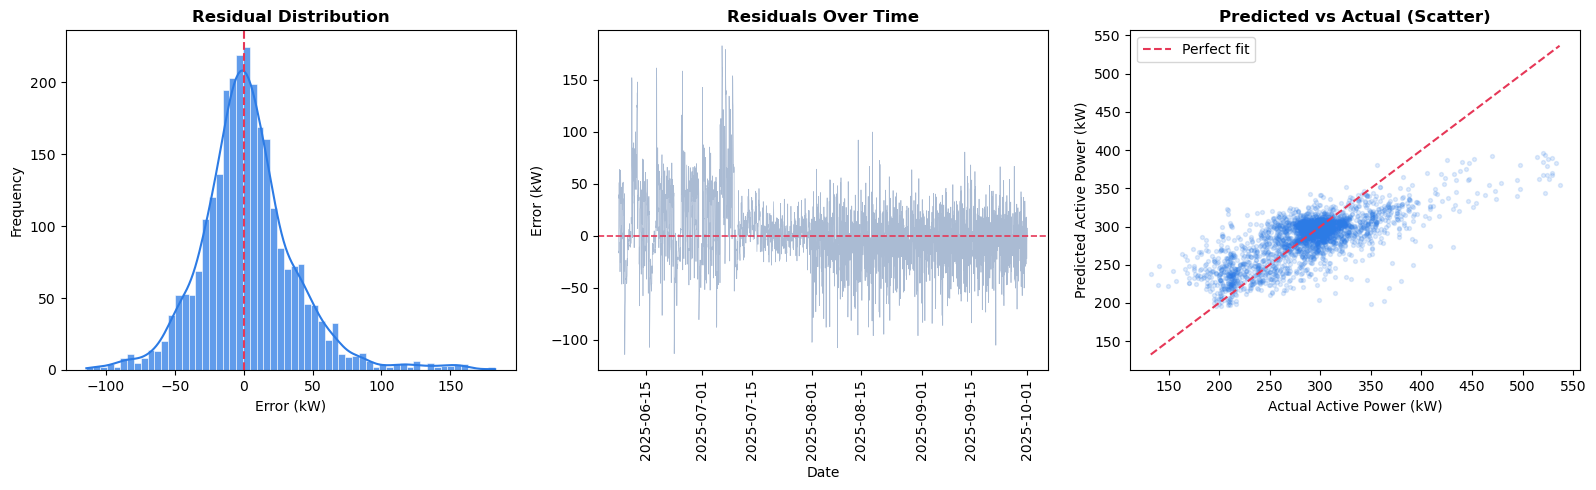

Mean residual (bias): 3.146kW
Mean residual Bias %: 1.090%
Residual std: 35.084kW
Max over-prediction: -114.323kW
Max under-prediction: 182.571kW


In [59]:
residuals = y_test_kw - y_pred_kw

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution of residuals
sns.histplot(residuals, kde=True, color="#2c7be5", bins=60, edgecolor="white", alpha=0.75, ax=axes[0])
axes[0].axvline(0, color="#e63757", linestyle="--", linewidth=1.5)
axes[0].set_title("Residual Distribution", weight="bold")
axes[0].set_xlabel("Error (kW)")
axes[0].set_ylabel("Frequency")

# Residuals over time
axes[1].plot(test_index, residuals, color="#95aac9", linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color="#e63757", linestyle="--", linewidth=1.2)
axes[1].set_title("Residuals Over Time", weight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Error (kW)")
axes[1].tick_params(axis='x', labelrotation=90)

# Predicted vs Actual scatter
axes[2].scatter(y_test_kw, y_pred_kw, alpha=0.15, s=8, color="#2c7be5")
lims = [min(y_test_kw.min(), y_pred_kw.min()), max(y_test_kw.max(), y_pred_kw.max())]
axes[2].plot(lims, lims, color="#e63757", linestyle="--", linewidth=1.5, label="Perfect fit")
axes[2].set_title("Predicted vs Actual (Scatter)", weight="bold")
axes[2].set_xlabel("Actual Active Power (kW)")
axes[2].set_ylabel("Predicted Active Power (kW)")
axes[2].legend()

plt.tight_layout()
plt.savefig("lstm_residual_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Mean residual (bias): {residuals.mean():.3f}kW")
print(f"Mean residual Bias %: {residuals.mean() / y_test_kw.mean() * 100:.3f}%")
print(f"Residual std: {residuals.std():.3f}kW")
print(f"Max over-prediction: {residuals.min():.3f}kW")
print(f"Max under-prediction: {residuals.max():.3f}kW")

#### Baseline Comparison  
The naive forecast predicts that the next hour's load equals the current hour's load. This is the standard lower-bound benchmark in the STLF literature, my model must outperform it to justify its complexity.

In [40]:
# Setting up the naive forecast: predicted load at hour t=actual load at hour t-1
persistence_pred = test_df[target].shift(1)

# Aligning the same evaluation window as the LSTM
persistence_pred_aligned = persistence_pred.loc[test_index].values
y_test_aligned = test_df[target].loc[test_index].values

valid = ~np.isnan(persistence_pred_aligned)
persistence_pred_aligned = persistence_pred_aligned[valid]
y_test_persistence = y_test_aligned[valid]

rmse_persist = np.sqrt(mean_squared_error(y_test_persistence, persistence_pred_aligned))
mae_persist = mean_absolute_error(y_test_persistence, persistence_pred_aligned)
mask_p = y_test_persistence > 1.0
mape_persist = np.mean(np.abs((y_test_persistence[mask_p] - persistence_pred_aligned[mask_p]) / y_test_persistence[mask_p])) * 100

comparison = pd.DataFrame({
    "Model": ["Persistence (naive)", "LSTM (this notebook)"],
    "RMSE (kW)": [rmse_persist, rmse],
    "MAE (kW)": [mae_persist, mae],
    "MAPE (%)": [mape_persist, mape]
})

print(comparison.to_string(index=False))

improvement = (mape_persist - mape) / mape_persist * 100

print(f"\nLSTM improves on the persistence baseline by {improvement:.1f}%.")

               Model  RMSE (kW)  MAE (kW)  MAPE (%)
 Persistence (naive)  33.684562 24.181477  8.827338
LSTM (this notebook)  35.225174 25.128857  8.868242

LSTM improves on the persistence baseline by -0.5%.


#### Regime-Split Evaluation  
The overall MAPE above blends two very different operating regimes visible in the test period: a volatile window and a much calmer one. This step evaluates the model and the persistence baseline separately on each, using both  
(a) the dataset's own `is_vacation` flag  
(b) the visually-observed changepoint.

In [41]:
# Persistence baseline aligned to the test index
persistence_pred_full = test_df[target].shift(1).loc[test_index].values
is_vacation_aligned = test_df['is_vacation'].loc[test_index].values

def regime_metrics(y_true, y_pred, mask):
    yt, yp = y_true[mask], y_pred[mask]
    valid = ~np.isnan(yp)
    yt, yp = yt[valid], yp[valid]
    rmse_ = np.sqrt(mean_squared_error(yt, yp))
    mae_ = mean_absolute_error(yt, yp)
    m = yt > 1.0
    mape_ = np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100
    return rmse_, mae_, mape_, len(yt)

changepoint = pd.Timestamp("2025-07-14")
early_mask = test_index < changepoint
late_mask = test_index >= changepoint

print(f"{'Segment':<38}{'n':>6}{'LSTM MAPE':>12}{'Persist MAPE':>14}")
for label, mask in [
    ("Vacation flag= 1", is_vacation_aligned == 1),
    ("Vacation flag= 0 (term-time)", is_vacation_aligned == 0),
    ("Volatile window (< 2025-07-14)", early_mask),
    ("Calm window (>= 2025-07-14)", late_mask),
]:
    rmse_l, mae_l, mape_l, n_l = regime_metrics(y_test_kw, y_pred_kw, mask)
    rmse_p, mae_p, mape_p, _ = regime_metrics(y_test_kw, persistence_pred_full, mask)
    print(f"{label:<38}{n_l:>6}{mape_l:>11.2f}%{mape_p:>13.2f}%")


Segment                                    n   LSTM MAPE  Persist MAPE
Vacation flag= 1                         210      11.53%         6.64%
Vacation flag= 0 (term-time)            2568       8.65%         9.01%
Volatile window (< 2025-07-14)           882      11.50%         7.04%
Calm window (>= 2025-07-14)             1896       7.65%         9.66%


#### SHAP Interpretability

GradientExplainer estimates each feature's contribution to each prediction relative to a background distribution drawn from the training set. The raw output shape is (samples, lookback, features) — collapsing across the 48 timesteps by taking the mean absolute SHAP value per feature, giving a single importance score per feature averaged across the sample.

In [42]:
np.random.seed(42)

# Setting up background: 200 random training sequences as reference distribution
bg_idx = np.random.choice(len(X_train_seq), size=200, replace=False)
X_bg = X_train_seq[bg_idx]

# Setting up explanation set: 200 random test sequences
ex_idx = np.random.choice(len(X_test_seq), size=200, replace=False)
X_explain = X_test_seq[ex_idx]

print(f"Background samples: {X_bg.shape[0]}")
print(f"Explanation samples: {X_explain.shape[0]}")

explainer = shap.GradientExplainer(model, X_bg)
raw_shap = explainer.shap_values(X_explain)

# GradientExplainer to return a list for single-output regression
shap_array = raw_shap[0] if isinstance(raw_shap, list) else raw_shap

# Ensuring shape is (samples, lookback, features)
if shap_array.ndim == 4:
    shap_array = shap_array.squeeze(-1)
if shap_array.shape[0] == LOOKBACK:
    shap_array = np.transpose(shap_array, (1, 0, 2))

# Collapsing timestep dimension: mean per (sample, feature)
shap_2d = np.abs(shap_array).mean(axis=1)

print(f"SHAP array shape: {shap_array.shape}")
print(f"SHAP 2D shape: {shap_2d.shape}")

Background samples: 200
Explanation samples: 200
SHAP array shape: (200, 48, 18)
SHAP 2D shape: (200, 18)


#### Global Feature Importance  


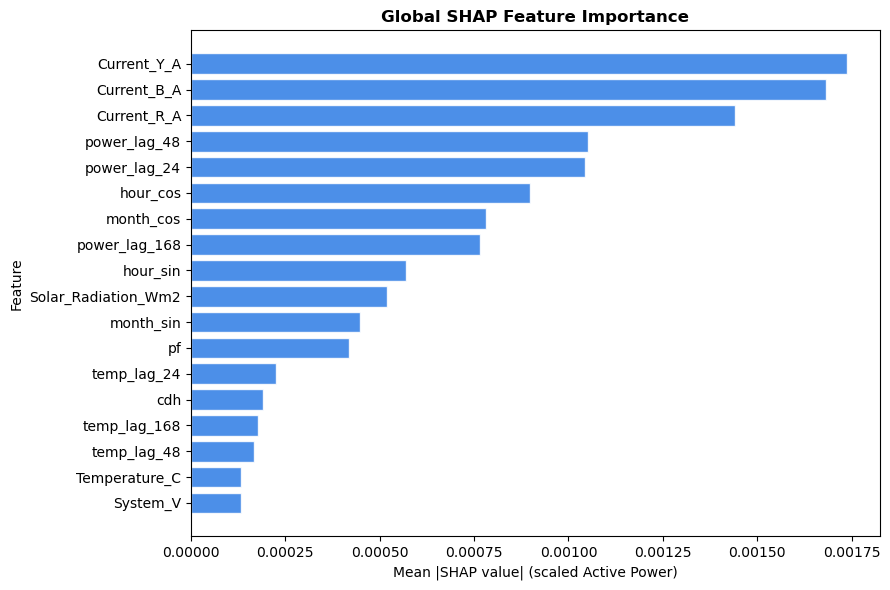

Top 5 features by global SHAP importance:
     Feature  Mean |SHAP|
 Current_Y_A     0.001737
 Current_B_A     0.001683
 Current_R_A     0.001442
power_lag_48     0.001051
power_lag_24     0.001044


In [43]:
mean_abs_shap = shap_2d.mean(axis=0)

# Global importance for shap importance
importance_df = pd.DataFrame({"Feature": features, "Mean |SHAP|": mean_abs_shap}).sort_values("Mean |SHAP|", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df["Feature"], importance_df["Mean |SHAP|"], color="#2c7be5", edgecolor="white", alpha=0.85)
ax.set_title("Global SHAP Feature Importance", weight="bold")
ax.set_xlabel("Mean |SHAP value| (scaled Active Power)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Top 5 features by global SHAP importance:\n{importance_df.sort_values('Mean |SHAP|', ascending=False).head(5).to_string(index=False)}")

#### SHAP Beeswarm

To show both the magnitude and direction of each feature's effect. Each dot is one prediction. Colour indicates feature value (red = high, blue = low). Points spreading right mean the feature pushes the prediction up; left means it pushes it down.

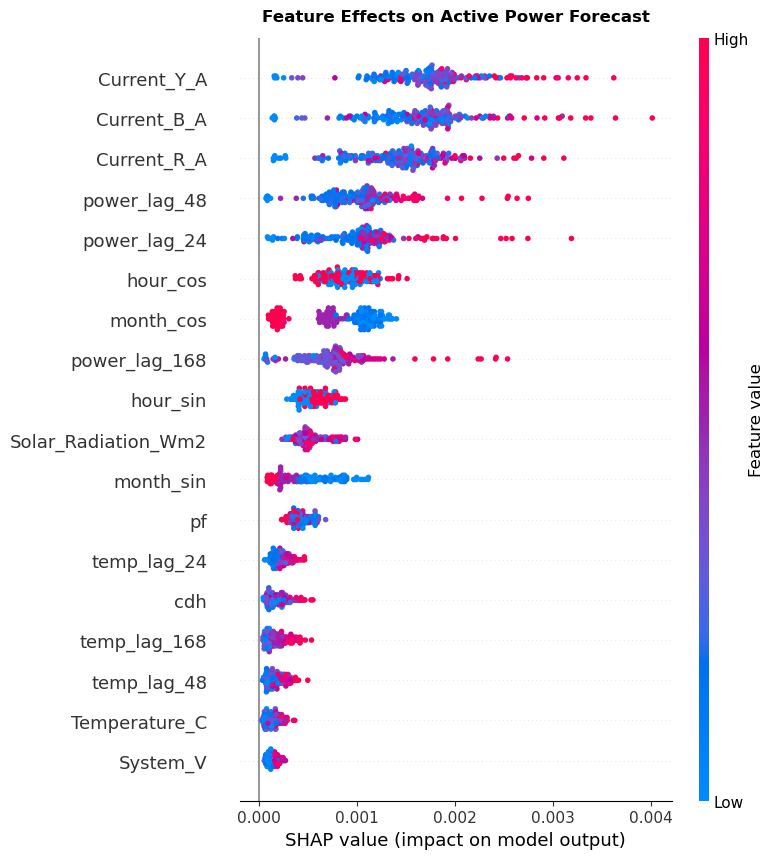

In [63]:
import matplotlib.ticker as ticker
# Beeswarm plot for SHAP values
X_explain_2d = X_explain.mean(axis=1)

shap.summary_plot(shap_2d, features=X_explain_2d, feature_names=features, 
                  plot_type="dot", max_display=len(features), show=False)

plt.title("Feature Effects on Active Power Forecast", weight="bold", pad=12)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.001))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

#### Peak vs Off-Peak  
Splits the 200 explanation samples by hour of day to show whether different features drive load predictions at different times. Peak hours (08:00–21:00) vs off-peak (22:00–07:00).

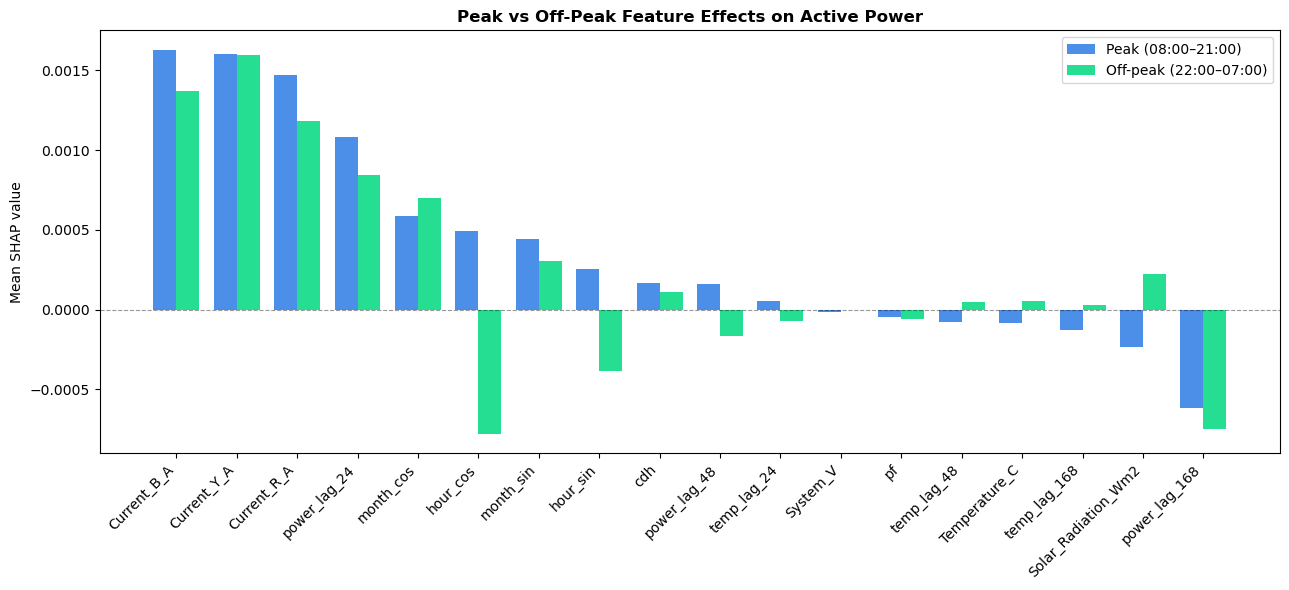

Peak hours — top 5 features:
     Feature  Peak SHAP
 Current_B_A   0.001631
 Current_Y_A   0.001601
 Current_R_A   0.001469
power_lag_24   0.001081
   month_cos   0.000584

Off-peak hours — top 5 features:
     Feature  Off-peak SHAP
 Current_Y_A       0.001596
 Current_B_A       0.001372
 Current_R_A       0.001186
power_lag_24       0.000845
   month_cos       0.000701


In [45]:
# Signed SHAP (not abs) — preserves direction
shap_signed_2d = shap_array.mean(axis=1)

# Get hour of day for each explanation sample
explain_hours = test_df.index[LOOKBACK:][ex_idx].hour

peak_mask = (explain_hours >= 8) & (explain_hours <= 21)
offpeak_mask = ~peak_mask

shap_peak = shap_signed_2d[peak_mask].mean(axis=0)
shap_offpeak = shap_signed_2d[offpeak_mask].mean(axis=0)

temporal_df = pd.DataFrame({
    "Feature": features,
    "Peak SHAP": shap_peak,
    "Off-peak SHAP": shap_offpeak
}).sort_values("Peak SHAP", ascending=False)

x = np.arange(len(features))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width/2, temporal_df["Peak SHAP"], width, color="#2c7be5", alpha=0.85, label="Peak (08:00–21:00)")
ax.bar(x + width/2, temporal_df["Off-peak SHAP"], width, color="#00d97e", alpha=0.85, label="Off-peak (22:00–07:00)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(temporal_df["Feature"], rotation=45, ha="right")
ax.set_title("Peak vs Off-Peak Feature Effects on Active Power", weight="bold")
ax.set_ylabel("Mean SHAP value")
ax.legend()
plt.tight_layout()
plt.savefig("shap_temporal.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Peak hours — top 5 features:\n{temporal_df[['Feature','Peak SHAP']].head(5).to_string(index=False)}")
print(f"\nOff-peak hours — top 5 features:\n{temporal_df[['Feature','Off-peak SHAP']].sort_values('Off-peak SHAP', ascending=False).head(5).to_string(index=False)}")

#### Final Summary  

Complete results in one place for the dissertation Results chapter.

In [46]:
print("Model Configuration")
print(f"Architecture: LSTM(64), Dropout(0.2), LSTM(32), Dropout(0.2), Dense(1)")
print(f"Loss: MSE")
print(f"Lookback: {LOOKBACK} hours")
print(f"Features: {N_FEATURES}  {features}")
print(f"Epochs run: {len(history.history['loss'])}")
print(f"Batch size: {batch_size}")

print("\nDeterministic Test Set Performance")
print(f"RMSE: {rmse:.3f} kW")
print(f"MAE: {mae:.3f} kW")
print(f"MAPE: {mape:.2f}%")

Model Configuration
Architecture: LSTM(64), Dropout(0.2), LSTM(32), Dropout(0.2), Dense(1)
Loss: MSE
Lookback: 48 hours
Features: 18  ['System_V', 'Current_R_A', 'Current_Y_A', 'Current_B_A', 'pf', 'Temperature_C', 'Solar_Radiation_Wm2', 'cdh', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'power_lag_24', 'power_lag_48', 'power_lag_168', 'temp_lag_24', 'temp_lag_48', 'temp_lag_168']
Epochs run: 39
Batch size: 64

Deterministic Test Set Performance
RMSE: 35.225 kW
MAE: 25.129 kW
MAPE: 8.87%


#### Post-Search Feature Engineering

In [47]:
# Current ratio 
i_max = data_df3[["Current_R_A", "Current_Y_A", "Current_B_A"]].max(axis=1)
i_min = data_df3[["Current_R_A", "Current_Y_A", "Current_B_A"]].min(axis=1)
data_df3["current_ratio"] = i_max / (i_min + 1e-3)

# Temperature rate of change
data_df3["temp_diff"] = data_df3["Temperature_C"].diff()

# Cooling degree hours
COOLING_BASE_TEMP = 24.0  # comfort baseline in degrees C
data_df3["cdh"] = (data_df3["Temperature_C"] - COOLING_BASE_TEMP).clip(lower=0)

# Temperature x time-of-day interaction
data_df3["temp_hour_interaction"] = data_df3["Temperature_C"] * data_df3["hour_sin"]

# Heat index / apparent temperature
vapour_pressure = (data_df3["Humidity_%"] / 100.0) * 6.105 * np.exp(17.27 * data_df3["Temperature_C"] / (237.7 + data_df3["Temperature_C"]))
data_df3["heat_index"] = data_df3["Temperature_C"] + 0.33 * vapour_pressure - 4.00

# Rolling std and solar lag
data_df3["roll_std_6"] = data_df3["Active_Power_kw"].shift(1).rolling(6).std()
data_df3["solar_lag_1"] = data_df3["Solar_Radiation_Wm2"].shift(1)
data_df3["solar_lag_2"] = data_df3["Solar_Radiation_Wm2"].shift(2)

# Weekend flag
data_df3["is_weekend"] = (data_df3.index.dayofweek >= 5).astype(int)


In [48]:
# Dropping rows with NaNs in candidate features
rows_before = len(data_df3)
data_df3 = data_df3.dropna()
print(f"Rows dropped (candidate-feature NaNs): {rows_before - len(data_df3)}")
print(f"Remaining rows: {len(data_df3)}")

# Adding features to the final feature set
features = base_features + lag_features + ["is_weekend"]

print("\nFinal Model Features:", features)
print(f"Total feature count: {len(features)}")


Rows dropped (candidate-feature NaNs): 6
Remaining rows: 18834

Final Model Features: ['System_V', 'Current_R_A', 'Current_Y_A', 'Current_B_A', 'pf', 'Temperature_C', 'Solar_Radiation_Wm2', 'cdh', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'power_lag_24', 'power_lag_48', 'power_lag_168', 'temp_lag_24', 'temp_lag_48', 'temp_lag_168', 'is_weekend']
Total feature count: 19


In [49]:
# Chronological split: 70% Train, 15% Val, 15% Test
n = len(data_df3)
train_df = data_df3.iloc[:int(n*0.7)]
val_df = data_df3.iloc[int(n*0.7):int(n*0.85)]
test_df = data_df3.iloc[int(n*0.85):]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_df[features])
X_val_scaled = scaler_X.transform(val_df[features])
X_test_scaled = scaler_X.transform(test_df[features])

y_train_scaled = scaler_y.fit_transform(train_df[[target]])
y_val_scaled = scaler_y.transform(val_df[[target]])
y_test_scaled = scaler_y.transform(test_df[[target]])

LOOKBACK = 48
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
X_val_seq, y_val_seq = create_sequences(X_val_scaled,   y_val_scaled,   LOOKBACK)
X_test_seq, y_test_seq = create_sequences(X_test_scaled,  y_test_scaled,  LOOKBACK)

N_FEATURES = X_train_seq.shape[2]
print(f"Input shape: ({LOOKBACK}, {N_FEATURES})")

Input shape: (48, 19)


In [50]:
tf.random.set_seed(42)
np.random.seed(42)

# Setting up a new LSTM model with the updated feature set
model_v2 = build_lstm(LOOKBACK, N_FEATURES)

# Setting up callbacks for the new model
early_stop_v2 = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)
checkpoint_v2 = ModelCheckpoint(filepath="best_lstm_model_v2.keras", monitor="val_loss", save_best_only=True, verbose=1)
reduce_lr_v2 = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1)

history_v2 = model_v2.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_v2, checkpoint_v2, reduce_lr_v2],
    shuffle=False,
    verbose=1)

print(f"\nTraining stopped at epoch: {len(history_v2.history['loss'])}")
print(f"Best val_loss: {min(history_v2.history['val_loss']):.6f}")


Epoch 1/100
204/206 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0790 - mae: 0.2098
Epoch 1: val_loss improved from None to 0.06972, saving model to best_lstm_model_v2.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0504 - mae: 0.1741 - val_loss: 0.0697 - val_mae: 0.2021 - learning_rate: 5.0000e-04
Epoch 2/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0257 - mae: 0.1288
Epoch 2: val_loss improved from 0.06972 to 0.03163, saving model to best_lstm_model_v2.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0239 - mae: 0.1229 - val_loss: 0.0316 - val_mae: 0.1356 - learning_rate: 5.0000e-04
Epoch 3/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0181 - mae: 0.1073
Epoch 3: val_loss improved from 0.03163 to 0.02981, saving model to best_lstm_model_v2.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0175 - mae: 0.1044 - val_loss: 0.0298 - val_mae: 0.1329 - learning_rate: 5.0000e-04
Epoch 4/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.016

In [51]:
# Evaluating the new model on the test set
y_pred_scaled_v2 = model_v2.predict(X_test_seq, batch_size=64)
y_pred_kw_v2 = scaler_y.inverse_transform(y_pred_scaled_v2).flatten()
y_test_kw_v2 = scaler_y.inverse_transform(y_test_seq).flatten()

rmse_v2 = np.sqrt(mean_squared_error(y_test_kw_v2, y_pred_kw_v2))
mae_v2  = mean_absolute_error(y_test_kw_v2, y_pred_kw_v2)
mask_v2 = y_test_kw_v2 > 1.0
mape_v2 = np.mean(np.abs((y_test_kw_v2[mask_v2] - y_pred_kw_v2[mask_v2]) / y_test_kw_v2[mask_v2])) * 100

print(f"{'Metric':<10} {'Value':>12}")
print(f"{'RMSE':<10} {rmse_v2:>10.3f} kW")
print(f"{'MAE':<10} {mae_v2:>10.3f} kW")
print(f"{'MAPE':<10} {mape_v2:>10.2f} %")

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Metric            Value
RMSE           35.484 kW
MAE            25.411 kW
MAPE             9.12 %


| # | Feature | Rationale | Test MAPE |  
|---|---|---|---|  
| 1 | `roll_std_6` — 6h rolling std of `Active_Power_kw` (shift(1) applied first, no leakage) | short-window volatility, distinct from the 24h version already rejected | 9.52% |  
| 2 | `current_ratio` — max/min phase current | alternative encoding of phase asymmetry to `phase_imbalance_pct` | 9.07% |  
| 3 | `solar_lag_1`, `solar_lag_2` | thermal lag between solar input and building cooling load | 9.46% |  
| 4 | `temp_diff` — `Temperature_C.diff()` | rate of warming/cooling, not just absolute level | 9.00% |  
| 5 | `cdh` — cooling degree hours, `max(0, Temperature_C − 24)` | standard energy-forecasting transform: "how far above comfort baseline" | 8.87% |  
| 6 | `temp_hour_interaction` — `Temperature_C × hour_sin` | lets temperature's effect on load vary by time of day | 9.14% |  
| 7 | `heat_index` — simplified apparent temperature (temperature + humidity) | humid heat drives cooling load harder than dry heat at the same temperature | 8.78% |  